# Passo 1

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats
import plotly.express as px
import plotly.graph_objects as go

In [3]:
df = pd.read_csv('dataframes/rest_data_us_upd.csv', dtype={'id': 'str', 'chain': 'category'})

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9651 entries, 0 to 9650
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   id           9651 non-null   object  
 1   object_name  9651 non-null   object  
 2   address      9651 non-null   object  
 3   chain        9648 non-null   category
 4   object_type  9651 non-null   object  
 5   number       9651 non-null   int64   
dtypes: category(1), int64(1), object(4)
memory usage: 386.6+ KB


In [5]:
df

,id,object_name,address,chain,object_type,number
0,11786,HABITAT COFFEE SHOP,3708 N EAGLE ROCK BLVD,False,Cafe,26
1,11787,REILLY'S,100 WORLD WAY 120,False,Restaurant,9
2,11788,STREET CHURROS,6801 HOLLYWOOD BLVD 253,False,Fast Food,20
3,11789,TRINITI ECHO PARK,1814 W SUNSET BLVD,False,Restaurant,22
4,11790,POLLEN,2100 ECHO PARK AVE,False,Restaurant,20
...,...,...,...,...,...,...
9646,21432,HALL OF JUSTICE,217 W TEMPLE AVE,False,Restaurant,122
9647,21433,FIN-MELROSE,5750 MELROSE AVE,False,Restaurant,93
9648,21434,JUICY WINGZ,6741 HOLLYWOOD BLVD,True,Fast Food,15
9649,21435,MEDIDATE COFFEE,548 S SPRING ST STE 100,False,Cafe,6


# Passo 3

#### Tarefa 1

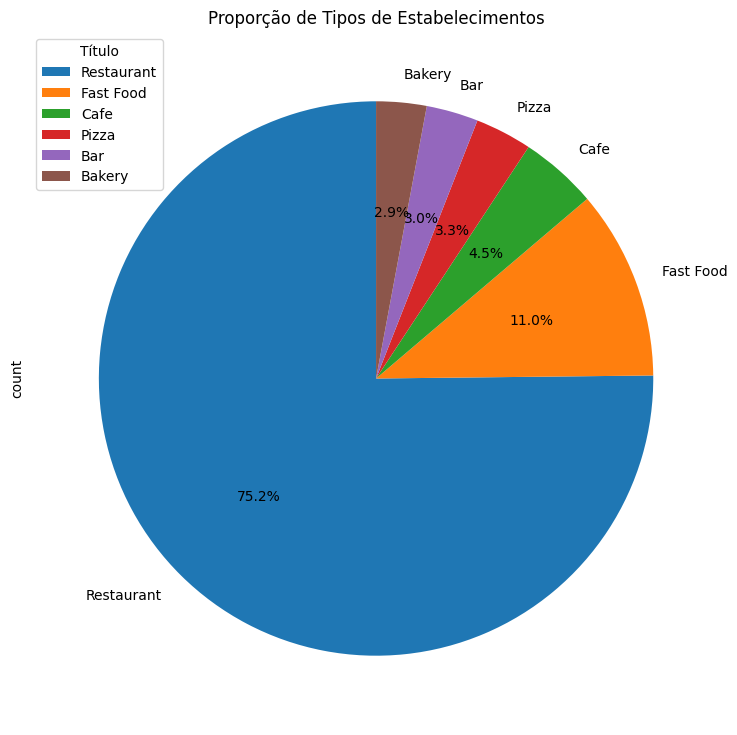

In [6]:
#Investigando as proporções de tipo de estabelecimentos.
df['object_type'].value_counts(normalize=True)
#Construindo gráfico de pizza para visualizar as proporções.
plt.figure(figsize=(9, 9))
df['object_type'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90)
plt.title('Proporção de Tipos de Estabelecimentos')
plt.legend(title='Título', loc='upper left')
plt.show()

##### Restaurantes são os mais comuns tipos de estabelecimento.

#### Tarefa 2

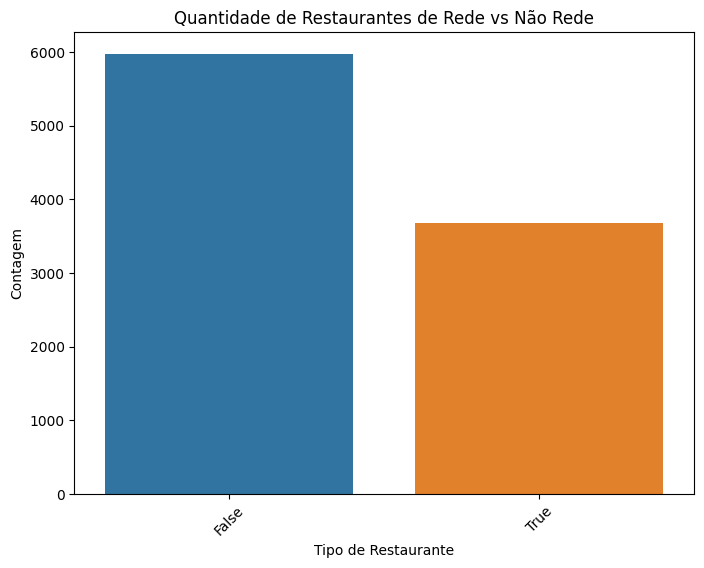

In [7]:
# Verificando quantos restaurantes são de rede e quantos não são.
df['chain'].value_counts()
# Construindo gráfico de barras para visualizar a quantidade de restaurantes de rede e não rede.
plt.figure(figsize=(8, 6))
sns.countplot(x='chain', data=df, hue='chain', legend=False)
plt.title('Quantidade de Restaurantes de Rede vs Não Rede')
plt.xlabel('Tipo de Restaurante')
plt.ylabel('Contagem')
plt.xticks(rotation=45)
plt.show()


##### A maioria dos comércios não são de rede.

#### Tarefa 3

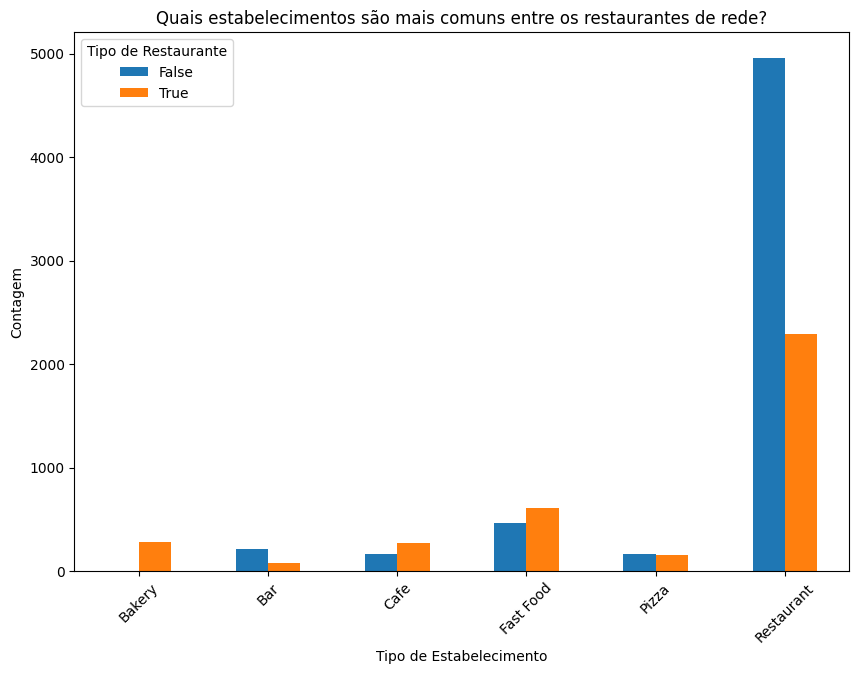

In [8]:
# Quais os tipos de estabelecimentos mais comuns entre os restaurantes de rede?
chain_counts = df.groupby('object_type')['chain'].value_counts().unstack(fill_value=0)
# Construindo gráfico de barras para visualizar os tipos de estabelecimentos mais comuns entre os restaurantes de rede.
chain_counts.plot(kind='bar', stacked=False, figsize=(10, 7))
plt.title('Quais estabelecimentos são mais comuns entre os restaurantes de rede?')
plt.xlabel('Tipo de Estabelecimento')
plt.ylabel('Contagem')
plt.xticks(rotation=45)
plt.legend(title='Tipo de Restaurante')
plt.show()

#### Durante a análise verifiquei que o mais comum são os cafés e fast foods serem restaurante de rede. Um ponto que foi anormal é o fato de todas as padarias estarem como restaurante de rede, o que aparenta ser incomum e uma possível falha nos dados.

#### Tarefa 4

In [9]:
# O que faz caracterizar um restaurante de rede? Quais são as características mais comuns entre os restaurantes de rede?
# Verificando as características mais comuns entre os restaurantes de rede.
chain_characteristics = df[df['chain'] == 'True'].reset_index(drop=True)
chain_number_median = chain_characteristics['number'].median()
chain_number_mean = chain_characteristics['number'].mean()
print(chain_characteristics)
print(f'Mediana do número de restaurantes de rede: {chain_number_median}')
print(f'Média do número de restaurantes de rede: {chain_number_mean}')

         id               object_name                          address chain  \
0     11794                ABC DONUTS  3027 N SAN FERNANDO RD UNIT 103  True   
1     11796             EL POLLO LOCO               5319 W SUNSET BLVD  True   
2     11797         POONG NYUN BAKERY        928 S WESTERN AVE STE 109  True   
3     11798  EMC RESTAURANT GROUP LLC            3500 W 6TH ST STE 101  True   
4     11800         CUSCATLECA BAKERY            2501 W SUNSET BLVD #A  True   
...     ...                       ...                              ...   ...   
3671  21415            JUCUAPA BAKERY             2810 JAMES WOOD BLVD  True   
3672  21422            CHIPOTLE #3094          6719 LA TIJERA BLVD A-B  True   
3673  21425                MCDONALD'S               1800 S WESTERN AVE  True   
3674  21434               JUICY WINGZ              6741 HOLLYWOOD BLVD  True   
3675  21436              CAFE SPROUTS      1300 S SAN PEDRO ST STE 111  True   

     object_type  number  
0      Fast 

         id          object_name                       address  chain  \
0     11786  HABITAT COFFEE SHOP        3708 N EAGLE ROCK BLVD  False   
1     11787             REILLY'S             100 WORLD WAY 120  False   
2     11788       STREET CHURROS       6801 HOLLYWOOD BLVD 253  False   
3     11789    TRINITI ECHO PARK            1814 W SUNSET BLVD  False   
4     11790               POLLEN            2100 ECHO PARK AVE  False   
...     ...                  ...                           ...    ...   
5967  21430      LA BUFADORA BAR                 3470 E 1ST ST  False   
5968  21431           SAINT MARC  10250 SANTA MONICA BLVD 1025  False   
5969  21432      HALL OF JUSTICE              217 W TEMPLE AVE  False   
5970  21433          FIN-MELROSE              5750 MELROSE AVE  False   
5971  21435      MEDIDATE COFFEE       548 S SPRING ST STE 100  False   

     object_type  number  
0           Cafe      26  
1     Restaurant       9  
2      Fast Food      20  
3     Restauran

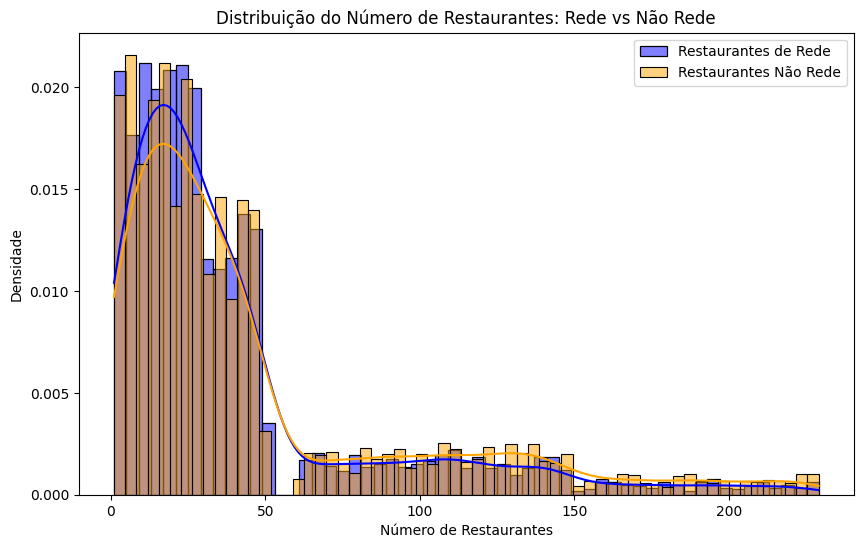

In [10]:
no_chain_characteristics = df[df['chain'] == 'False'].reset_index(drop=True)
no_chain_number_median = no_chain_characteristics['number'].median()
no_chain_number_mean = no_chain_characteristics['number'].mean()
print(no_chain_characteristics)
print(f'Mediana do número de restaurantes não rede: {no_chain_number_median}')
print(f'Média do número de restaurantes não rede: {no_chain_number_mean}')
# Plotanfo um histograma para comparar a distribuição do número de restaurantes entre os restaurantes de rede e não rede.
plt.figure(figsize=(10, 6))
sns.histplot(chain_characteristics['number'], color='blue', label='Restaurantes de Rede', kde=True, stat='density')
sns.histplot(no_chain_characteristics['number'], color='orange', label='Restaurantes Não Rede', kde=True, stat='density')
plt.title('Distribuição do Número de Restaurantes: Rede vs Não Rede')
plt.xlabel('Número de Restaurantes')
plt.ylabel('Densidade')
plt.legend()
plt.show()

##### Não foi verificado uma grande distinção entre o número de cadeiras em restaurantes de rede e restaurantes que não são de rede. A maior diferença como já observado no gráfico anterior é por tipo de estabelecimento.

#### Tarefa 5

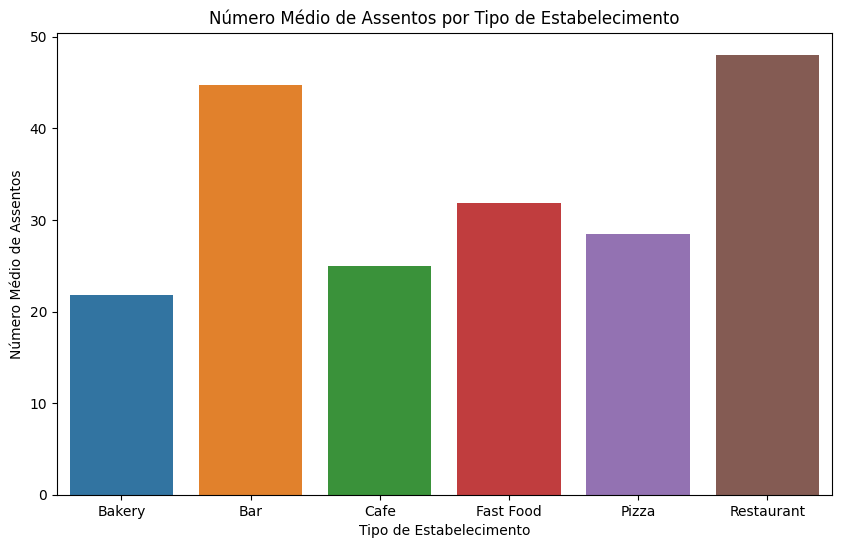

In [11]:
# Determinando o número médio de assento em diferentes tipos de restaurantes.
object_type_seats = df.groupby('object_type')['number'].mean().reset_index()
# Construindo gráfico de barras para visualizar o número médio de assentos em diferentes tipos de restaurantes.
plt.figure(figsize=(10, 6))
sns.barplot(x='object_type', y='number', data=object_type_seats, hue='object_type', legend=False)
plt.title('Número Médio de Assentos por Tipo de Estabelecimento')
plt.xlabel('Tipo de Estabelecimento')
plt.ylabel('Número Médio de Assentos')
plt.show()



#### Bares e Restaurantes tem o maior número de assentos tendo em vista que comumente é o tipo de estabelecimentos onde as pessoas mais passam o tempo, diferentes do restante que são ou mais voltados para refeições rápidas(Fast Food e Cafe) ou voltadas para pedidos de retiradas (Bakery e Pizzarias)

#### Tarefa 6

In [12]:
# Separando o número dos endereços do nome da rua para analisar a distribuição do número de endereços.
df['address_road'] = df['address'].apply(lambda x: ' '.join(x.split(' ')[1:]))
print(df)

         id          object_name                      address  chain  \
0     11786  HABITAT COFFEE SHOP       3708 N EAGLE ROCK BLVD  False   
1     11787             REILLY'S            100 WORLD WAY 120  False   
2     11788       STREET CHURROS      6801 HOLLYWOOD BLVD 253  False   
3     11789    TRINITI ECHO PARK           1814 W SUNSET BLVD  False   
4     11790               POLLEN           2100 ECHO PARK AVE  False   
...     ...                  ...                          ...    ...   
9646  21432      HALL OF JUSTICE             217 W TEMPLE AVE  False   
9647  21433          FIN-MELROSE             5750 MELROSE AVE  False   
9648  21434          JUICY WINGZ          6741 HOLLYWOOD BLVD   True   
9649  21435      MEDIDATE COFFEE      548 S SPRING ST STE 100  False   
9650  21436         CAFE SPROUTS  1300 S SAN PEDRO ST STE 111   True   

     object_type  number            address_road  
0           Cafe      26       N EAGLE ROCK BLVD  
1     Restaurant       9         

#### Tarefa 7

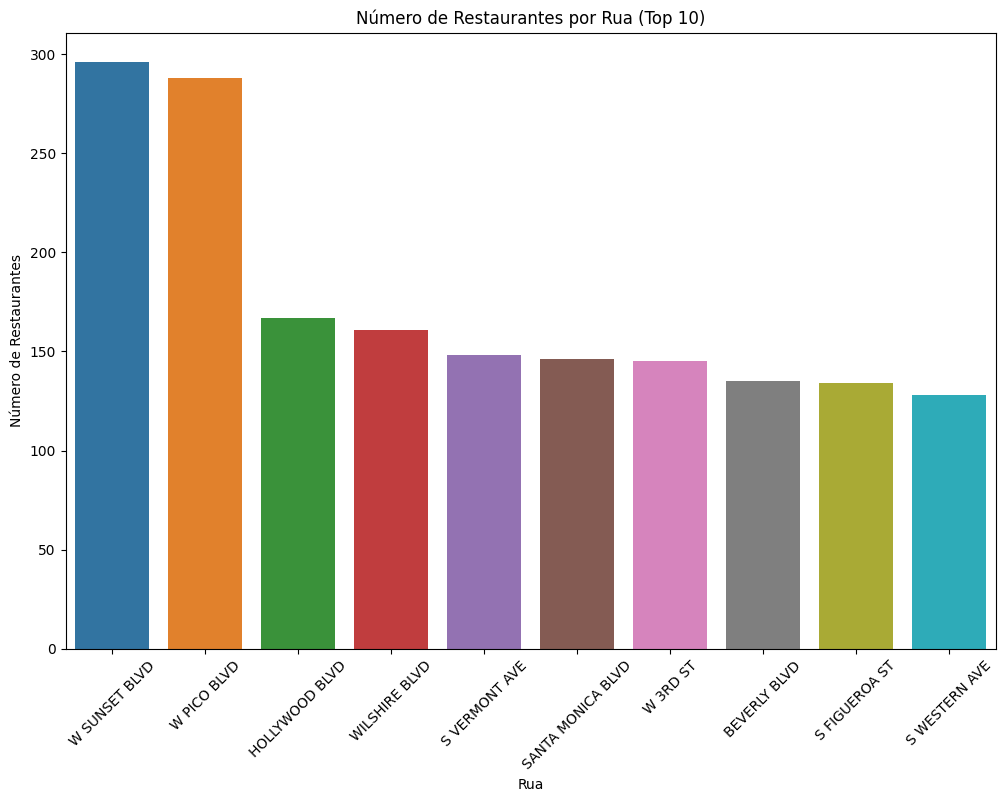

In [22]:
number_of_restaurants_by_road = df['address_road'].value_counts().reset_index(name='count')

# Construindo gráfico de barras para visualizar a distribuição do número de restaurantes por rua.
plt.figure(figsize=(12, 8))
sns.barplot(x='address_road', y='count', data=number_of_restaurants_by_road.head(10), hue='address_road', legend=False)
plt.title('Número de Restaurantes por Rua (Top 10)')
plt.xlabel('Rua')
plt.ylabel('Número de Restaurantes')
plt.xticks(rotation=45)
plt.show()


#### Tarefa 8

In [27]:
roads_with_1_restaurant = number_of_restaurants_by_road[number_of_restaurants_by_road['count'] == 1]
print(roads_with_1_restaurant)

                address_road  count
627            WORLD WAY T45      1
628               W 6TH ST 1      1
629   W OLYMPIC BLVD STE 202      1
630    S WESTERN AVE STE #40      1
631          W PICO BLVD 204      1
...                      ...    ...
3072                EVANS ST      1
3073         N BROADWAY BLVD      1
3074             GATEWAY PLZ      1
3075       S ATLANTIC BLVD A      1
3076        S VIRGIL AVE 100      1

[2450 rows x 2 columns]


#### Foi verificado que há 2450 ruas com apenas um restaurante, o que pode ser novamente uma informação falha, visto que ao final dos endereços tem ruas que possuem outro número que deve ser referente a bloco, apartamento ou outra forma de nomenclatura de separação.

#### Tarefa 9

        address_road  count
0      W SUNSET BLVD    296
1        W PICO BLVD    288
2     HOLLYWOOD BLVD    167
3      WILSHIRE BLVD    161
4      S VERMONT AVE    148
5  SANTA MONICA BLVD    146
6           W 3RD ST    145
7       BEVERLY BLVD    135
8      S FIGUEROA ST    134
9      S WESTERN AVE    128


C:\Users\João\AppData\Local\Temp\ipykernel_25632\3091848866.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Rua')


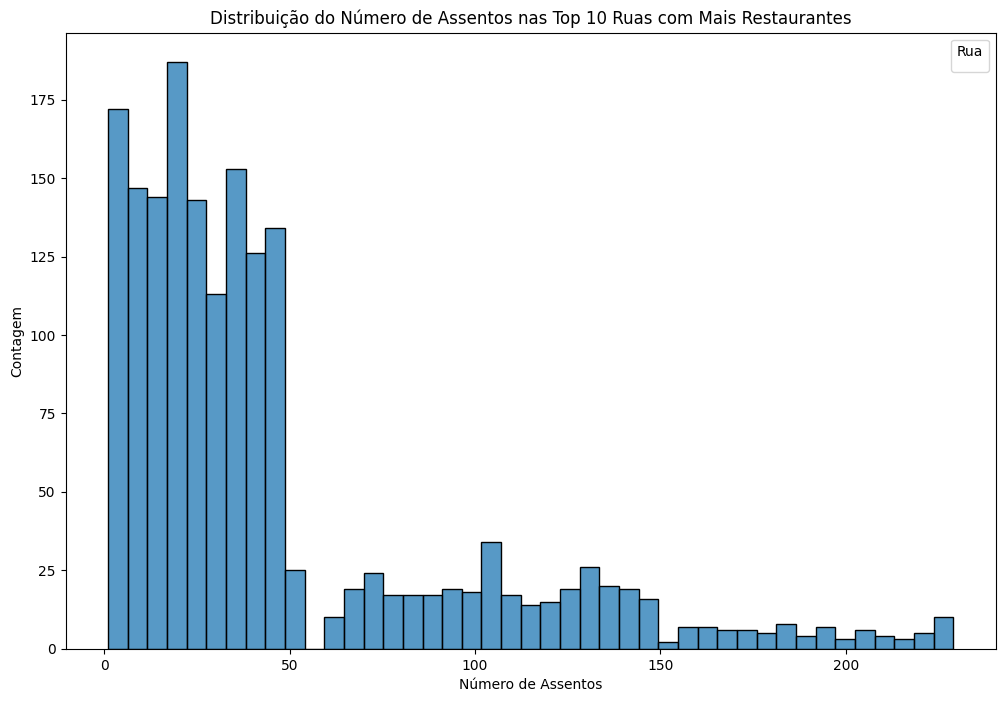

In [31]:
# Verificando a distribuição de numero de assentos nas top 10 ruas com mais restaurantes.

top_10_roads = number_of_restaurants_by_road.head(10)
print(top_10_roads)
number_of_seats_by_road = df[df['address_road'].isin(top_10_roads['address_road'])]
# Construindo histograma para visualizar a distribuição do número de assentos nas top 10 ruas com mais restaurantes.
plt.figure(figsize=(12, 8))
sns.histplot(data=number_of_seats_by_road, x='number', multiple='stack')
plt.title('Distribuição do Número de Assentos nas Top 10 Ruas com Mais Restaurantes')
plt.xlabel('Número de Assentos')
plt.ylabel('Contagem')
plt.legend(title='Rua')
plt.show()


#### Notei que tem uma semelhança muito grande com o gráfico já mostrado anteriormente, mostrando que mesmo com uma menor amostragem ou uma amostragem retirada específicamente de um ponto os estabelecimentos no geral tendem a se comportar de uma maneira semelhante.

#### Com base na análise geral realizada consigo concluir que a melhor das oportunidades seria uma pizzaria de mais ou menos 40-45 assentos localizada na Santa Monica BLVD, já que é um estabelecimento que não tem tantos no geral, idenpendente se seja de rede ou não e estaria localizada em uma rua que tem um bom número de comércios portanto sugere que ela tenha boa movimentação, mas não é a rua com maior número de comércios o que traz menores competições.